In [9]:
import torch
import numpy as np
import normflows as nf
import random as rd

from matplotlib import pyplot as plt
from tqdm import tqdm

## Generate Data
Three Gaussian clusters (centres at (1,1), (5,5) and (8,1); N=100 points each) are sampled and returned as a float32 torch tensor together with integer class labels (0, 10, 20).

In [10]:
rd.seed(42)
def generate_dummy_cluster_datasets(N = 100):
    # Set three centers
    center_1 = np.array([1,1])
    center_2 = np.array([5,5])
    center_3 = np.array([8,1])

    # Generate random data and center it to the three centers
    cluster_1 = np.random.randn(N,2) + center_1
    cluster_2 = np.random.randn(N,2) + center_2
    cluster_3 = np.random.randn(N,2) + center_3

    data = np.concatenate((cluster_1, cluster_2, cluster_3), axis = 0)
    y_data = np.zeros(data.shape[0])
    idx = 0
    for d in data:
        y_data[idx] = 10.*int(idx/100)
        idx +=1
    #data = np.c_[ data, y_data ]  
    
    res = torch.tensor(data).to(torch.float32)
    return res, y_data

## Visualize the Data
Scatter-plot the 300 original data points, coloured by class label (red, green, cyan).

torch.float32


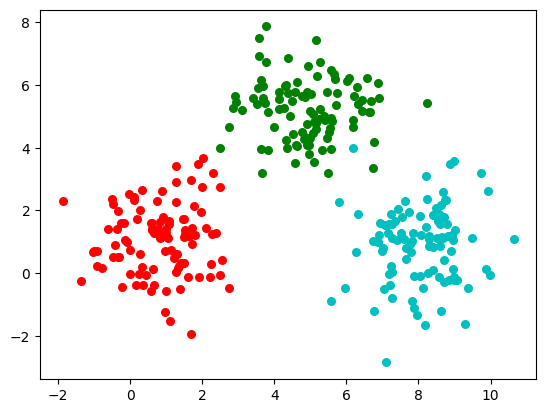

In [11]:
N = 100
data, y_data = generate_dummy_cluster_datasets(N)
print(data.dtype)
colors = ["r", "g", "c"]

idx = 0
for d in data:
    plt.scatter(d[0], d[1], color = colors[int(y_data[idx]/10)],s = 30)
    idx +=1


## Set up the Normalizing Flow Model
Construct a 32-layer Affine Coupling flow on a 2-D diagonal Gaussian base distribution and move the model to the available device (CPU/CUDA).

In [12]:
# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(2)

# Define list of flows
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([1, 64, 64, 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))
    
# Construct flow model
model = nf.NormalizingFlow(base, flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)
device

device(type='cpu')

## Prepare and Test Plotting
Define a helper that evaluates the model log-density on a 200×200 grid and renders it as a colour-map. Call it once to visualise the untrained (prior) distribution.

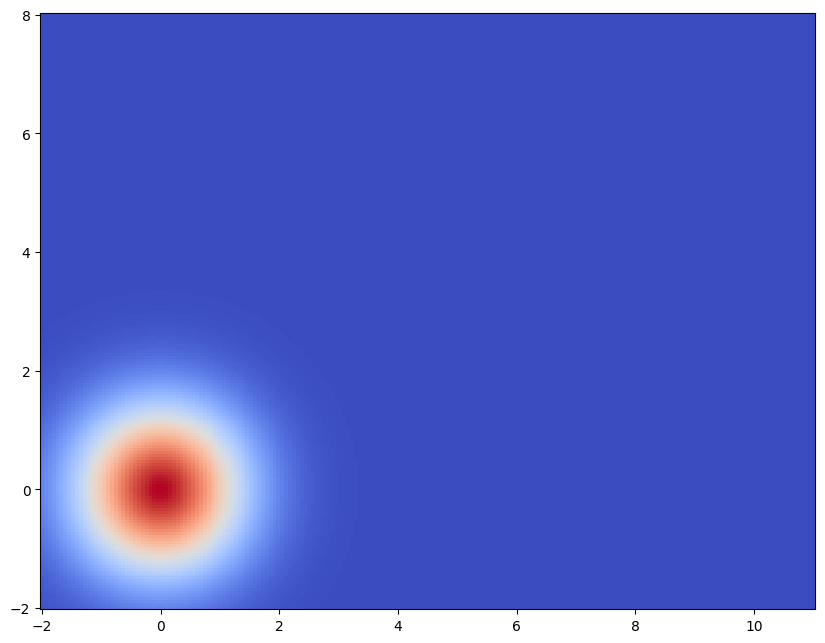

In [13]:
grid_size = 200
xx, yy = torch.meshgrid(torch.linspace(-2, 11, grid_size), torch.linspace(-2, 8, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
#zz = torch.column_stack((zz, torch.zeros(grid_size*grid_size)))
zz = zz.to(device)

def plot_model():
    model.eval()
    log_prob = model.log_prob(zz)
    model.train()
    prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
    prob[torch.isnan(prob)] = 0

    plt.figure(figsize=(10, 10))
    plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
    plt.gca().set_aspect('equal', 'box')
    plt.show()

plot_model()

## Train the Model
Minimise the forward KL divergence for 4000 iterations using Adam (lr=5e-4). The learned density is plotted every 500 steps; the final training-loss curve is shown at the end.

 12%|█▏        | 498/4000 [00:39<04:47, 12.19it/s]

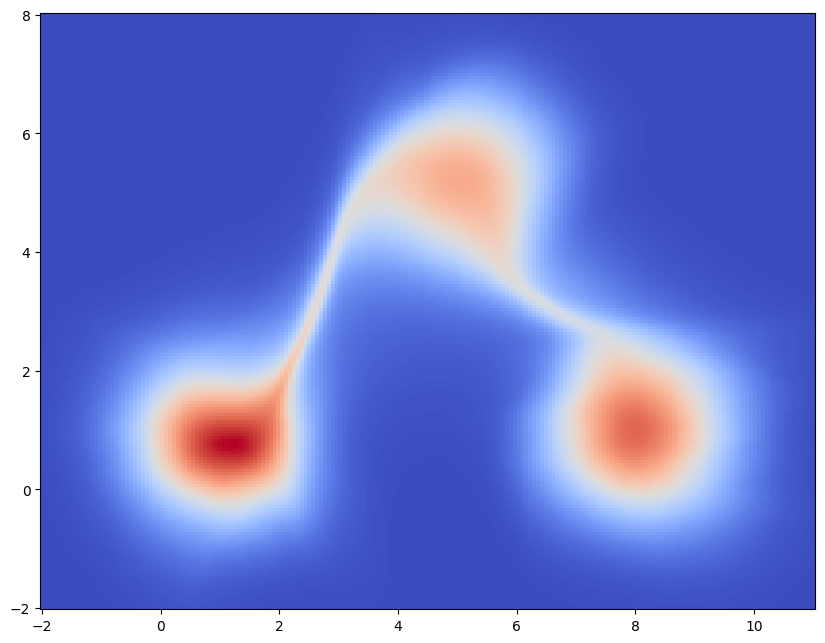

 25%|██▍       | 999/4000 [01:17<03:42, 13.49it/s]

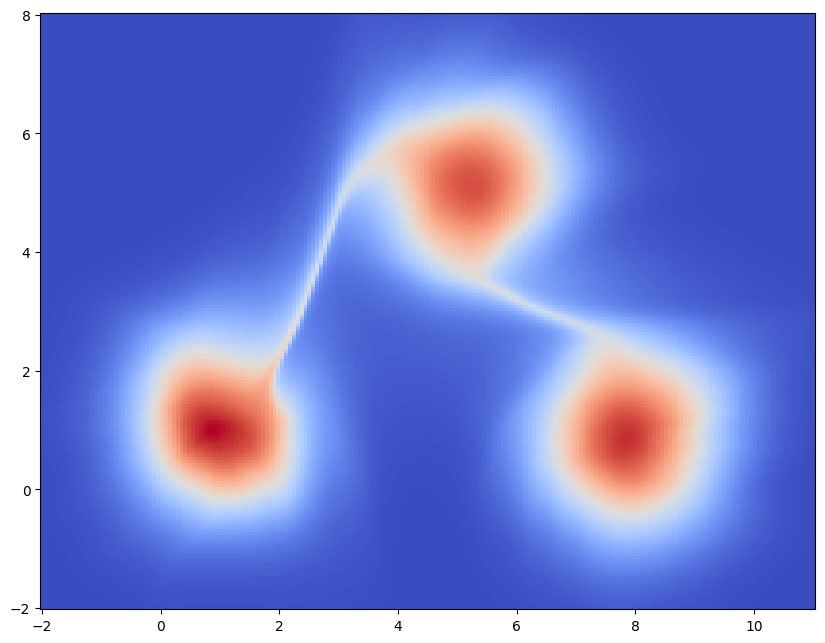

 37%|███▋      | 1498/4000 [01:56<03:56, 10.56it/s]

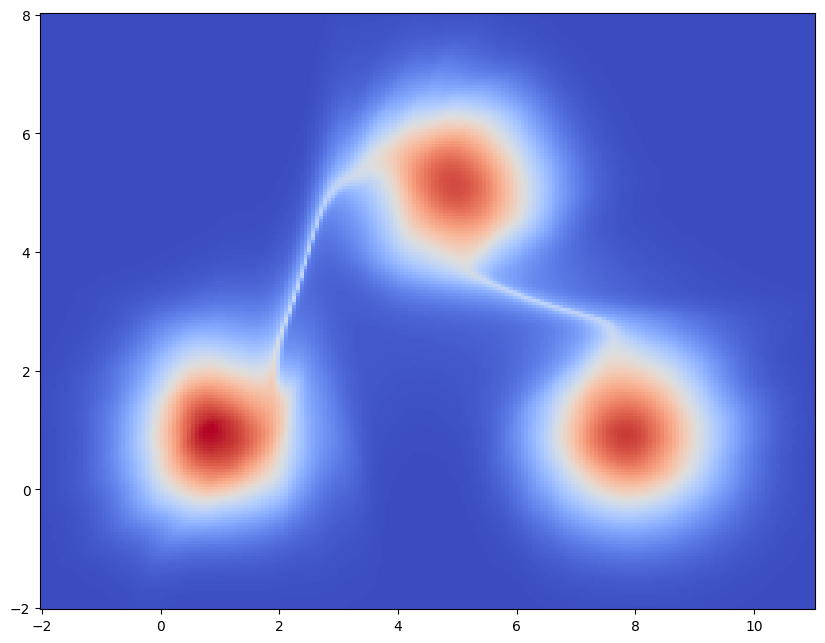

 50%|████▉     | 1999/4000 [02:38<02:34, 12.97it/s]

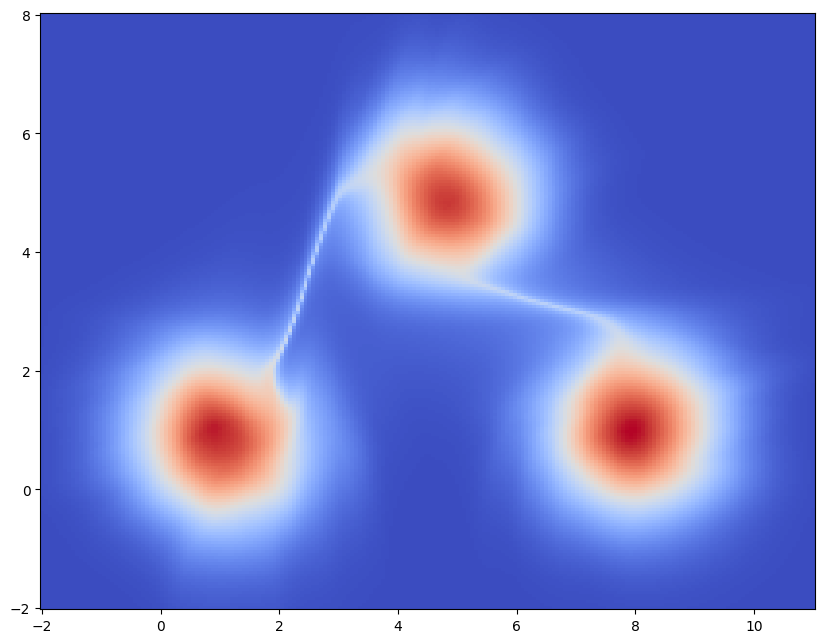

 62%|██████▏   | 2498/4000 [03:19<02:34,  9.73it/s]

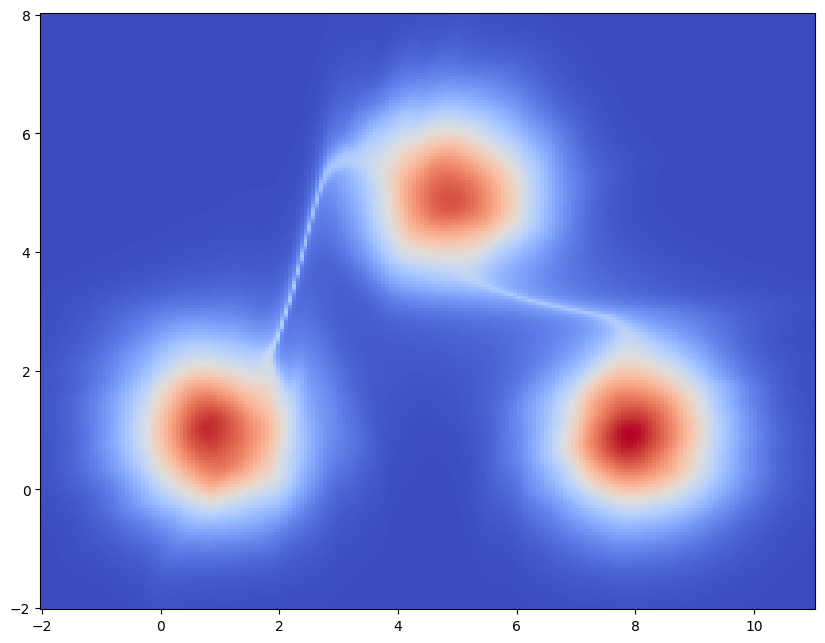

 75%|███████▍  | 2999/4000 [04:06<01:31, 10.96it/s]

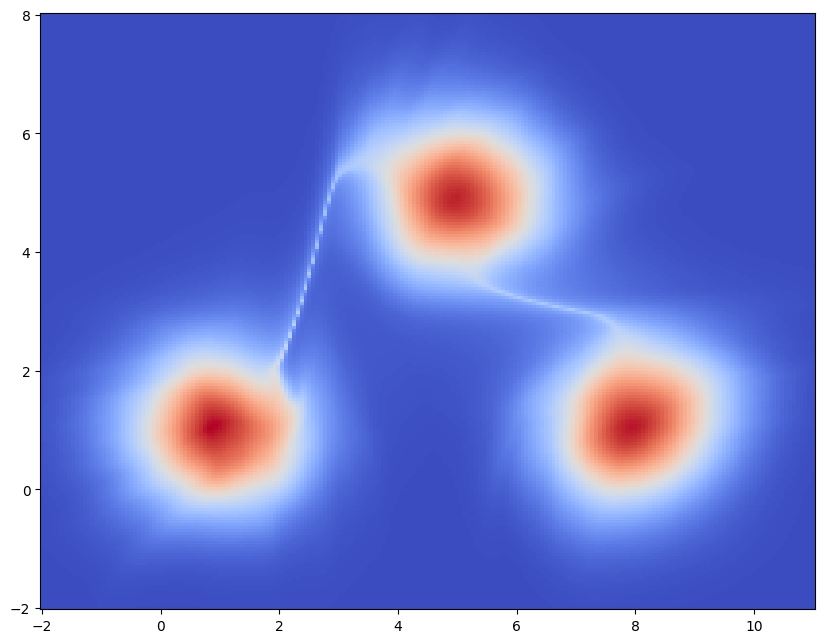

 87%|████████▋ | 3499/4000 [04:49<00:46, 10.76it/s]

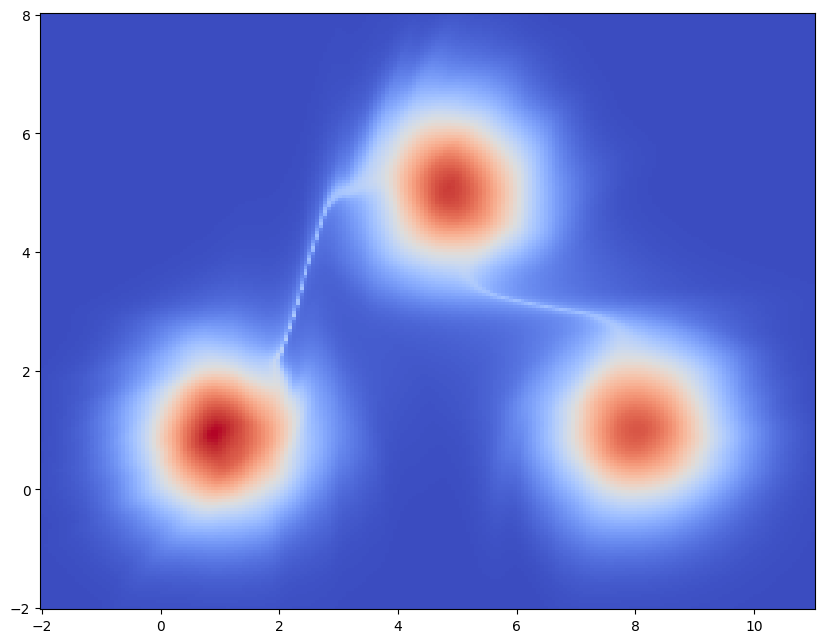

100%|█████████▉| 3998/4000 [05:33<00:00, 11.68it/s]

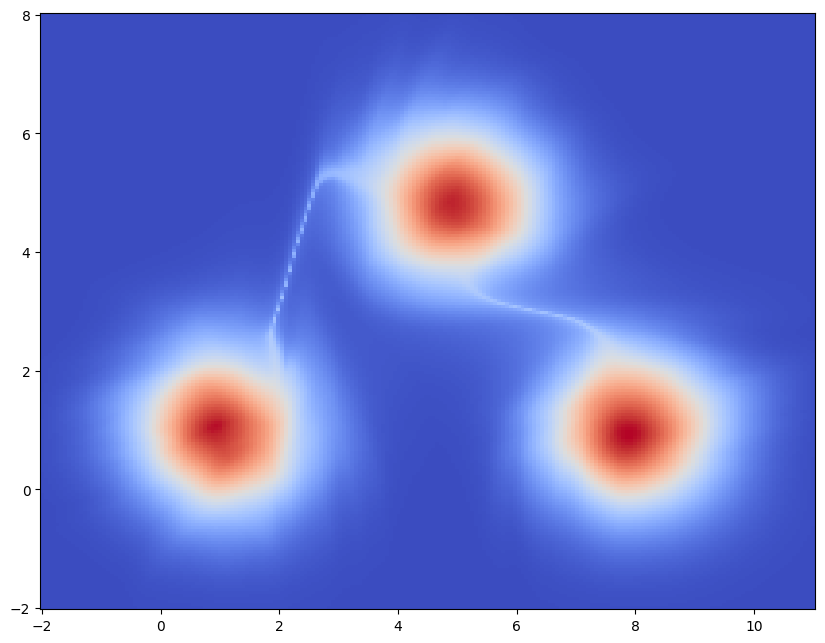

100%|██████████| 4000/4000 [05:34<00:00, 11.95it/s]


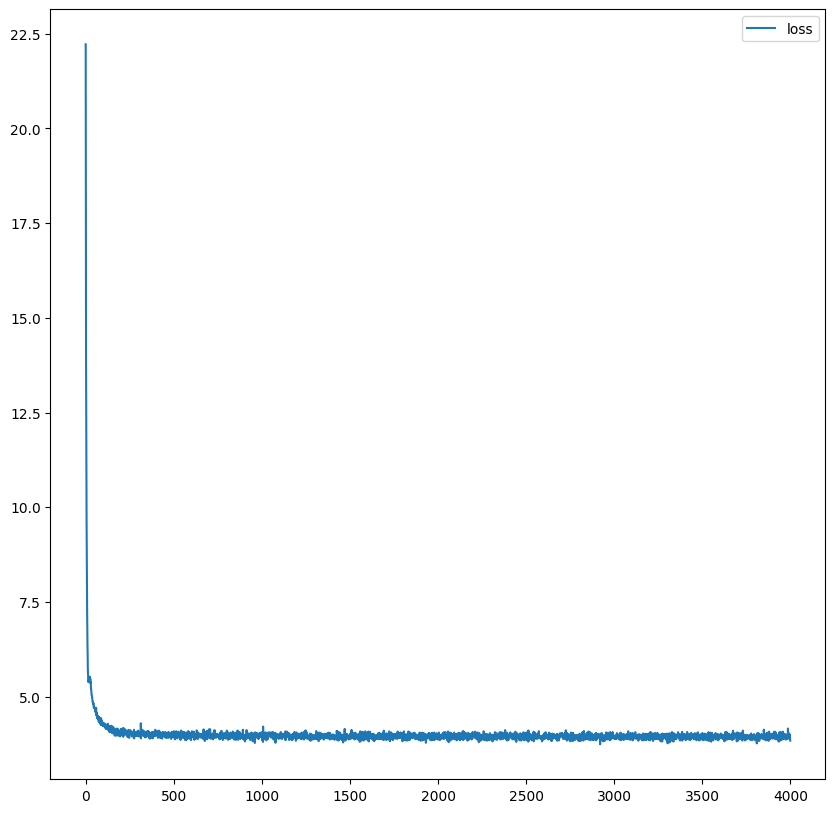

In [14]:
max_iter = 4000
show_iter = 500

loss_hist = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    
    # Get training samples
    data, y_data = generate_dummy_cluster_datasets(N)
    x = data.to(device)
    
    # Compute loss
    loss = model.forward_kld(x)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
    # Plot learned distribution
    if (it + 1) % show_iter == 0:
        plot_model()
        
# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

## Generate Synthetic Data
Sample 1000 new points from the trained flow in no-grad mode and scatter-plot them to verify that the generated distribution matches the original clusters.

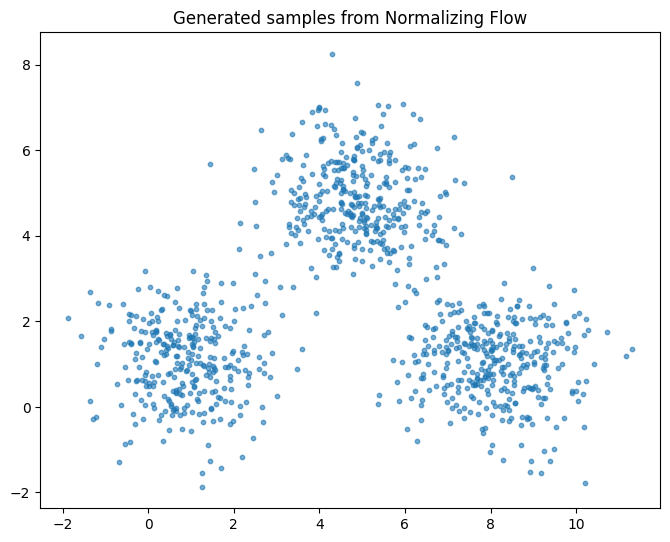

In [15]:
model.eval()

num_samples = 1000

with torch.no_grad():
    samples, log_q = model.sample(num_samples)
    samples = samples.cpu().numpy()

plt.figure(figsize=(8,8))
plt.scatter(samples[:,0], samples[:,1], s=10, alpha=0.6)
plt.title("Generated samples from Normalizing Flow")
plt.gca().set_aspect('equal', 'box')
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

## Evaluate Synthetic Data Quality
### 1 — Cluster original data; compare clusters to true labels
Apply K-Means (k=3) to the original data *without* using class labels. Measure how well the unsupervised clustering agrees with the true labels (Hungarian-algorithm matching).

/Users/wlomsi/Documents/ProjekteUni/Vorlesungen/ML 4DV660+4DV661+4DV652/Public ML Notebooks/.venv/lib/python3.10/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Clustering accuracy (original data vs. true labels): 0.9933


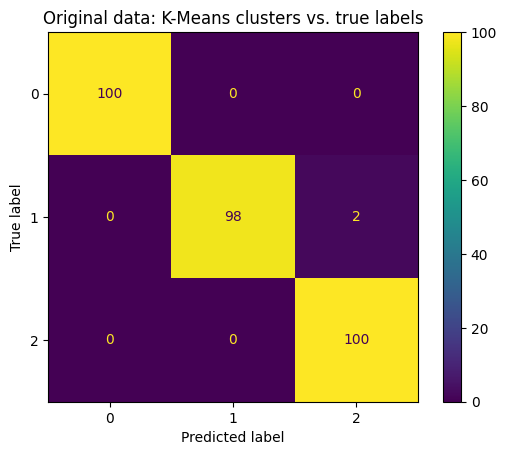

In [17]:
data_np = data.cpu().numpy()
y_true = (y_data / 10).astype(int)  # remap 0, 10, 20 -> 0, 1, 2

kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_orig = kmeans_orig.fit_predict(data_np)

# Align cluster indices to true labels via Hungarian algorithm
cm_raw = confusion_matrix(y_true, labels_orig)
row_ind, col_ind = linear_sum_assignment(-cm_raw)
label_map = {c: r for r, c in zip(row_ind, col_ind)}
labels_orig_matched = np.array([label_map[l] for l in labels_orig])

acc = accuracy_score(y_true, labels_orig_matched)
print(f"Clustering accuracy (original data vs. true labels): {acc:.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_true, labels_orig_matched)).plot()
plt.title("Original data: K-Means clusters vs. true labels")
plt.show()

### 2 — Cluster synthetic data; compare cluster statistics to original
Apply K-Means (k=3) to the NF-generated samples. Align synthetic clusters to original clusters by centroid distance, then compare per-cluster mean and standard deviation.

In [18]:
kmeans_synth = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_synth = kmeans_synth.fit_predict(samples)

# Align synthetic clusters to original clusters by centroid proximity
dist_centers = cdist(kmeans_orig.cluster_centers_, kmeans_synth.cluster_centers_)
row_ind, col_ind = linear_sum_assignment(dist_centers)
synth_map = {s: o for o, s in zip(row_ind, col_ind)}
labels_synth_aligned = np.array([synth_map[l] for l in labels_synth])

hdr = f"{'Cluster':>8}  {'Mean orig':>20}  {'Std orig':>20}  {'Mean synth':>20}  {'Std synth':>20}  {'n_orig':>7}  {'n_synth':>8}"
print(hdr)
print("-" * len(hdr))
for c in range(3):
    op = data_np[labels_orig == c]
    sp = samples[labels_synth_aligned == c]
    print(f"{c:>8}  {str(op.mean(axis=0).round(3)):>20}  {str(op.std(axis=0).round(3)):>20}  "
          f"{str(sp.mean(axis=0).round(3)):>20}  {str(sp.std(axis=0).round(3)):>20}  {len(op):>7}  {len(sp):>8}")

 Cluster             Mean orig              Std orig            Mean synth             Std synth   n_orig   n_synth
-------------------------------------------------------------------------------------------------------------------
       0         [4.847 4.984]         [0.975 0.815]         [4.892 4.842]         [1.038 0.969]       98       343
       1         [8.005 1.1  ]         [0.979 1.011]         [8.073 1.031]         [1.085 0.877]      102       350
       2         [1.014 1.095]         [0.89  0.981]         [0.884 1.081]         [0.97  0.964]      100       307


### 3 — Distance analysis (re-identification risk)
For each synthetic point compute its distance to every original point and report the nearest-neighbour distance. A distribution skewed toward zero signals a re-identification risk.

Median nearest distance (synthetic → original): 0.1748
Mean nearest distance:                          0.2375
Near-zero distances (< 0.001):              0.00%


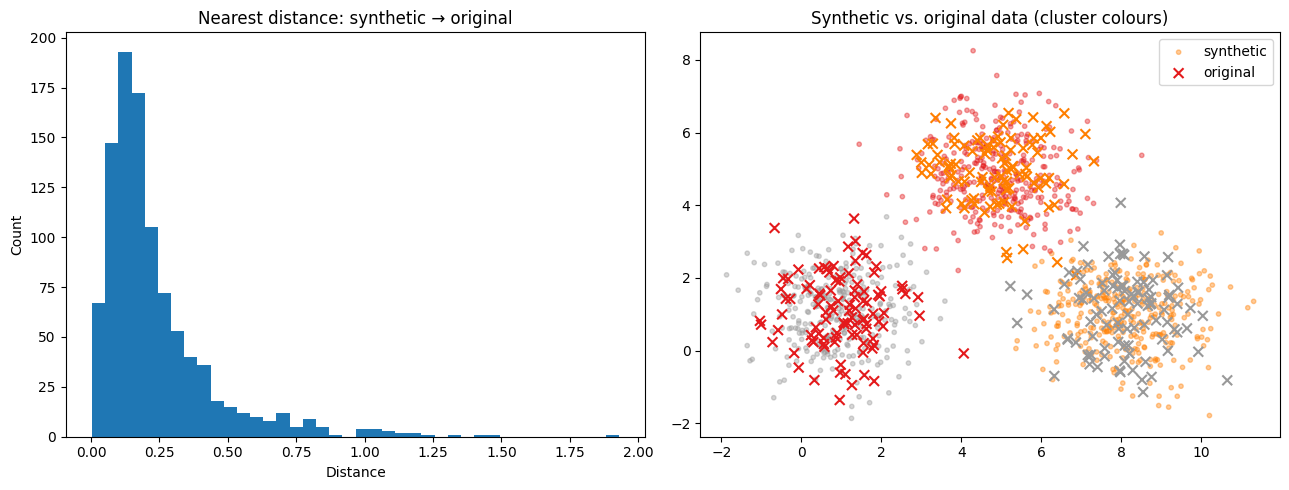

In [19]:
all_dists = cdist(samples, data_np)       # (n_synth, n_orig)
nearest_dist = all_dists.min(axis=1)

epsilon = 0.001
print(f"Median nearest distance (synthetic → original): {np.median(nearest_dist):.4f}")
print(f"Mean nearest distance:                          {np.mean(nearest_dist):.4f}")
print(f"Near-zero distances (< {epsilon}):              {(nearest_dist < epsilon).mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(nearest_dist, bins=40)
axes[0].set_title("Nearest distance: synthetic → original")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")

axes[1].scatter(samples[:, 0], samples[:, 1], c=labels_synth_aligned,
                cmap='Set1', s=10, alpha=0.4, label='synthetic')
axes[1].scatter(data_np[:, 0], data_np[:, 1], c=y_true,
                cmap='Set1', s=50, marker='x', linewidths=1.5, label='original')
axes[1].set_title("Synthetic vs. original data (cluster colours)")
axes[1].legend()

plt.tight_layout()
plt.show()